In [1]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings

warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
from sklearn.neighbors import KNeighborsClassifier


### Read the input file and check the data dimension

In [2]:
df = pd.read_csv('german_credit.csv')
df.shape

(1000, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [4]:
df.isnull().values.any()

False

In [5]:
df.isnull().values.sum()

0

In [6]:
df.isna().values.any()

False

In [7]:
df.isna().values.sum()

0

In [8]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
default,1000.0,0.300,0.458487,0.0,0.0,0.0,1.00,1.0
duration_in_month,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_as_income_perc,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
present_res_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
credits_this_bank,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
people_under_maintenance,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


In [10]:
df.shape

(1000, 21)

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [11]:
df.head()

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [12]:
from scipy.stats import zscore
X = df.drop('default',axis=1)
Y = df['default']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.5, random_state=0)

In [15]:
# Lets build an Ensemble model but need to modify the dataset first

### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [16]:
# Print Shape of model data
X_train.shape

(500, 20)

In [17]:
df.shape

(1000, 21)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [19]:
X = pd.get_dummies(df, drop_first = True)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 49 columns):
default                                                                       1000 non-null int64
duration_in_month                                                             1000 non-null int64
credit_amount                                                                 1000 non-null int64
installment_as_income_perc                                                    1000 non-null int64
present_res_since                                                             1000 non-null int64
age                                                                           1000 non-null int64
credits_this_bank                                                             1000 non-null int64
people_under_maintenance                                                      1000 non-null int64
account_check_status_< 0 DM                                                   1000 non-null uint8
account_chec

### Check for highly correlated variables but don't required any treatment for this use case

Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

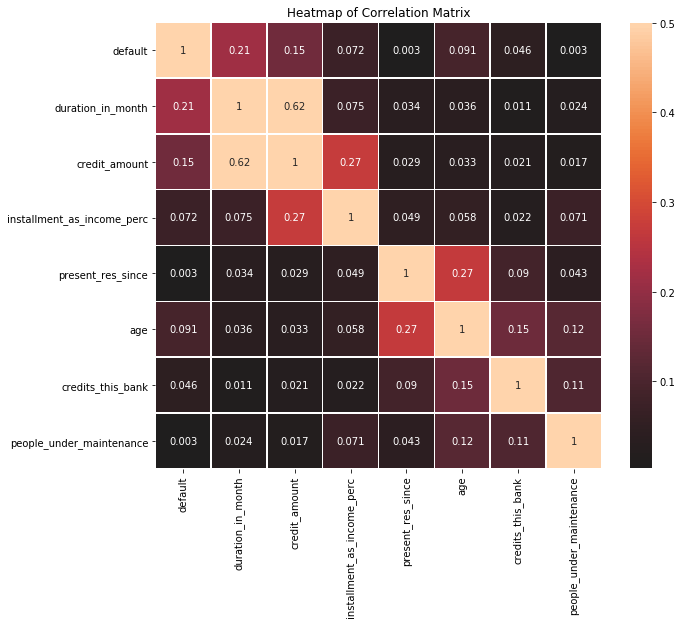

In [20]:
#Correlation among continuous variables
col_names =df.columns
corr_matrix = df[col_names].corr().abs()
plt.figure(figsize = (10,10))
cmap = sns.diverging_palette(500, 10, as_cmap=True)
sns.heatmap(corr_matrix,annot=True, xticklabels=corr_matrix.columns.values, yticklabels=corr_matrix.columns.values, vmax=.5, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Heatmap of Correlation Matrix')

In [21]:
#default is more correlated to duration in month and credit amount
#duration_in_month and credit_amount are correlated more to each other than other variables

### Drop the original variables which are converted to dummy

In [22]:
df.drop(['account_check_status',
'credit_history',
'purpose',
'savings',
'present_emp_since',
'personal_status_sex',
'other_debtors',
'property',
'other_installment_plans',
'housing',
'job',
'telephone',
'foreign_worker'],axis=1,inplace=True)

In [23]:
df.shape

(1000, 8)

In [24]:
df.head()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
0,0,6,1169,4,4,67,2,1
1,1,48,5951,2,2,22,1,1
2,0,12,2096,2,3,49,1,2
3,0,42,7882,2,4,45,1,2
4,1,24,4870,3,4,53,2,2


In [25]:
#drop na variables is not required since there are no na values
#df.dropna(inplace=True)

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [26]:
X = df.drop('default',axis=1)
Y = df[['default']]
X = X.apply(zscore) #(normalize all values)

In [27]:
X.head()

,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
0,-1.236478,-0.745131,0.918477,1.046987,2.766456,1.027079,-0.428290
1,2.248194,0.949817,-0.870183,-0.765977,-1.191404,-0.704926,-0.428290
2,-0.738668,-0.416562,-0.870183,0.140505,1.183312,-0.704926,2.334869
3,1.750384,1.634247,-0.870183,1.046987,0.831502,-0.704926,2.334869
4,0.256953,0.566664,0.024147,1.046987,1.535122,1.027079,2.334869


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn import metrics,svm
from sklearn import preprocessing
from sklearn import utils
from sklearn.model_selection import GridSearchCV

In [30]:
model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999)
model.fit(X_train, y_train)
model_pred=model.predict(X_test)
metrics.accuracy_score(y_test,model_pred)

0.71

In [31]:
model = RandomForestClassifier(criterion='entropy',random_state=0)

model.fit(X_train, y_train)

parameter={'n_estimators': np.arange(1,10), 'max_depth':np.arange(1,10),'criterion' : ['entropy','gini']}  
GS=GridSearchCV(model,parameter,cv=3)                                          
GS.fit(X_train,y_train)

print(GS.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'n_estimators': 6}


In [32]:
gs_pred=GS.predict(X_test)
metrics.accuracy_score(y_test,gs_pred)

0.7133333333333334

In [33]:
model = RandomForestClassifier(n_jobs=2, max_depth= 3,n_estimators=6,criterion="gini",random_state=9999)
model.fit(X_train, y_train)
model_pred=model.predict(X_test)
metrics.accuracy_score(y_test,model_pred)

0.7166666666666667

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [34]:
Y_predict=model.predict(X_test)
cm=metrics.confusion_matrix(y_test,Y_predict)
cm

array([[210,   4],
       [ 81,   5]], dtype=int64)

In [35]:
y_pred=model.predict(X_test)
accuracy = metrics.accuracy_score(y_test,y_pred)
accuracy

0.7166666666666667

### Q6 Show the list of the features importance( 1 Marks)

In [36]:
feature_importances = pd.DataFrame(model.feature_importances_,
                                   index = X_train.columns,
                                    columns=['importance']).sort_values('importance', ascending=False)
feature_importances

,importance
credit_amount,0.461789
duration_in_month,0.183279
age,0.175513
installment_as_income_perc,0.100219
credits_this_bank,0.039361
people_under_maintenance,0.023242
present_res_since,0.016597


### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [37]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [38]:
tmp = df.drop("default", axis=1)
tmp = tmp.apply(zscore) #(normalize all values)
X = tmp.as_matrix ()
y = df.loc[:, ['default']].as_matrix ()

In [39]:
# Use below values
num_folds = 10
seed = 77

# Validate the Random Forest model build above using k fold

# Q8 Print the confusion matrix( 1 Marks)¶

In [40]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

scores = []
cv = model_selection.KFold(n_splits=num_folds, random_state=42, shuffle=False)
for train_index, test_index in cv.split(df):
    X_train, X_test, y_train, y_test = X[train_index], X[test_index], y[train_index], y[test_index]
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    scores.append(score)
    y_pred = model.predict(X_test)
    print ("Confusion matrix: ")
    print (confusion_matrix(y_test, y_pred))
    print (" ")

Confusion matrix: 
[[74  1]
 [24  1]]
 
Confusion matrix: 
[[67  1]
 [31  1]]
 
Confusion matrix: 
[[75  2]
 [23  0]]
 
Confusion matrix: 
[[71  1]
 [24  4]]
 
Confusion matrix: 
[[72  0]
 [28  0]]
 
Confusion matrix: 
[[59  0]
 [41  0]]
 
Confusion matrix: 
[[69  1]
 [29  1]]
 
Confusion matrix: 
[[67  1]
 [29  3]]
 
Confusion matrix: 
[[70  1]
 [26  3]]
 
Confusion matrix: 
[[67  1]
 [30  2]]
 


# Calculate Mean score
# Calculate score standard deviation using std()

model score mean:  0.7060000000000001
cv_score mean: 0.705

model score variance:  0.0021040000000000004
cv_score variance:  0.00016499999999999973

model score std.dev:  0.045869379764718866
cv_score std.dev:  0.012845232578665119


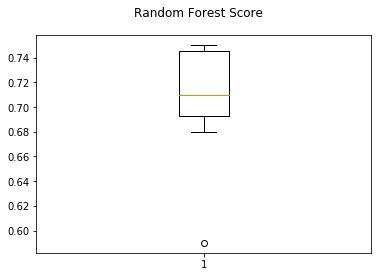

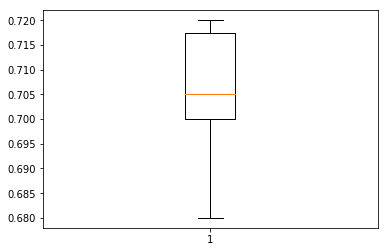

In [41]:
results = cross_val_score(model, X, Y, cv=num_folds, scoring='accuracy')
y_pred = cross_val_predict(model, X, y, cv = num_folds)

print("model score mean: ", np.mean(scores))
print("cv_score mean:", np.mean(results))
print("")
print("model score variance: ", np.var(scores))
print("cv_score variance: ", np.var(results))
print("")
print("model score std.dev: ", np.std(scores))
print("cv_score std.dev: ", np.std(results))


# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Random Forest Score')
ax = fig.add_subplot(111)
plt.boxplot(scores)
plt.show()

plt.boxplot(results)
plt.show()

# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [42]:
X = df.drop('default',axis=1)
Y = df[['default']]
X = X.apply(zscore) #(normalize all values)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.7, random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
conf_mat = confusion_matrix(y_test, y_pred)

In [43]:
accuracies = cross_val_score(model, X_test, y_test, cv = num_folds)
print("Mean score: ", accuracies.mean())
print("Std Deviation score: ", accuracies.std())

Mean score:  0.7028571428571428
Std Deviation score:  0.02373321103690879


In [44]:
# calculate accuracy
from sklearn import metrics
print("Accuracy: ", metrics.accuracy_score(y_test, y_pred))

print("Accuracy Range: %0.2f (+/- %0.2f)" % (accuracies.mean(), accuracies.std() * 2))

print("")
print("Confusion Matrix:")
print(conf_mat)
print("")

TP = conf_mat[1, 1]
TN = conf_mat[0, 0]
FP = conf_mat[0, 1]
FN = conf_mat[1, 0]

print(' Percentage of correct predictions:  ', ((TP + TN) / float(TP + TN + FP + FN) * 100))

Accuracy:  0.7014285714285714
Accuracy Range: 0.70 (+/- 0.05)

Confusion Matrix:
[[479  11]
 [198  12]]

 Percentage of correct predictions:   70.14285714285714


In [45]:
#Sensitivity
sensitivity = TP / float(FN + TP)

print("Sensitivity:" , sensitivity)
print("Recall:" , metrics.recall_score(y_test, y_pred))
print("Precision:" , metrics.precision_score(y_test, y_pred))

Sensitivity: 0.05714285714285714
Recall: 0.05714285714285714
Precision: 0.5217391304347826


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [46]:
#Hint: Use roc_curve

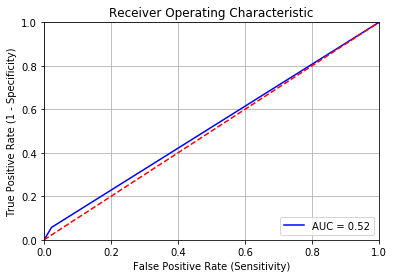

In [47]:
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.rcParams['font.size'] = 12
plt.ylabel('True Positive Rate (1 - Specificity)')
plt.xlabel('False Positive Rate (Sensitivity)')
plt.grid(True)
plt.show()

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [48]:
# IMPORTANT: first argument is true values, second argument is predicted probabilities
print(metrics.roc_auc_score(y_test, y_pred))

0.5173469387755102


### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [49]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [50]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    model.fit(X_, y_)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [51]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.6962857142857144
Standard deviation:  0.006101187572589322
